# Phase 11 – Regression Outputs

This notebook visualizes regression outputs generated by the C++ ML Core practical workflow.

It reads exported CSV files only. It does **not** train models or reimplement model logic in Python.

Input files:

```txt
outputs/practical-exercises/regression/metrics.csv
outputs/practical-exercises/regression/predictions.csv
outputs/practical-exercises/regression/loss_history.csv
```


## 1. Load exported outputs

The notebook is expected to be run from:

```txt
notebooks/practical-workflows/
```

so paths are resolved relative to the notebook location.


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("../../outputs/practical-exercises/regression")

metrics_path = OUTPUT_DIR / "metrics.csv"
predictions_path = OUTPUT_DIR / "predictions.csv"
loss_history_path = OUTPUT_DIR / "loss_history.csv"

for path in [metrics_path, predictions_path, loss_history_path]:
    if not path.exists():
        raise FileNotFoundError(f"Missing required output file: {path}")

metrics = pd.read_csv(metrics_path)
predictions = pd.read_csv(predictions_path)
loss_history = pd.read_csv(loss_history_path)

print("metrics:", metrics.shape)
print("predictions:", predictions.shape)
print("loss_history:", loss_history.shape)


metrics: (16, 7)
predictions: (400, 9)
loss_history: (257, 7)


## 2. Metrics table

The metrics file contains one row per model and metric.

Expected metrics:

```txt
mse
rmse
mae
r2
```


In [2]:
metrics_pivot = (
    metrics
    .pivot_table(
        index="model",
        columns="metric",
        values="value",
        aggfunc="first",
    )
    .reset_index()
)

metrics_pivot


metric,model,mae,mse,r2,rmse
0,DecisionTreeRegressor,0.020380,0.001116,-0.501129,0.033400
1,GradientBoostingRegressor,0.017635,0.000806,-0.084666,0.028391
2,LinearRegression,0.018250,0.000860,-0.157033,0.029323
3,RidgeRegression,0.018239,0.000859,-0.156311,0.029314


## 3. Metric comparison plots

Lower is better for:

```txt
mse
rmse
mae
```

Higher is better for:

```txt
r2
```


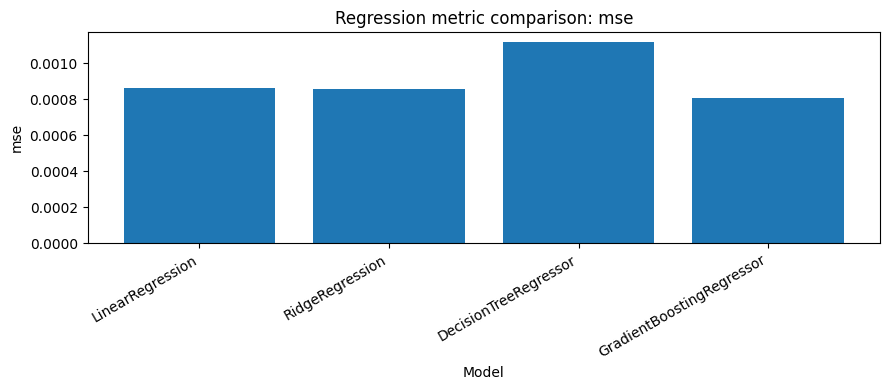

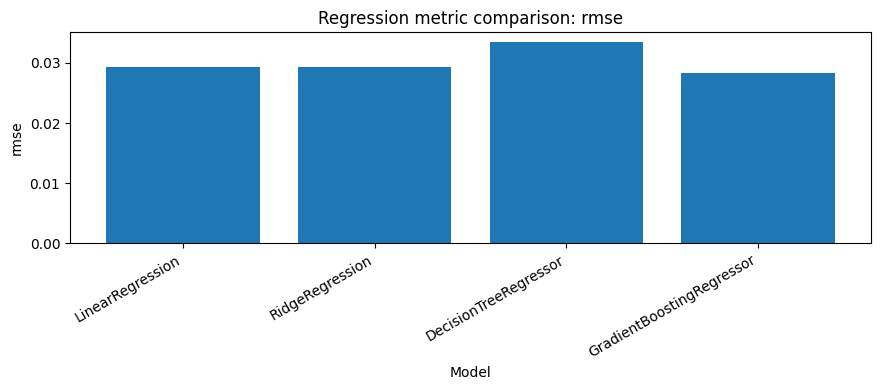

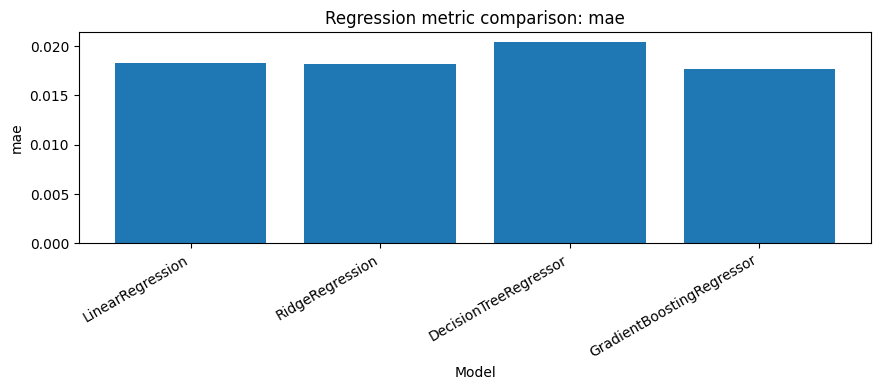

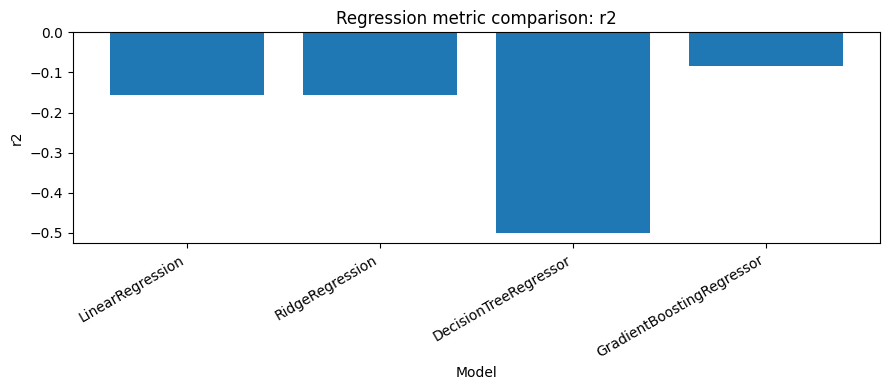

In [3]:
for metric_name in ["mse", "rmse", "mae", "r2"]:
    subset = metrics[metrics["metric"] == metric_name].copy()

    plt.figure(figsize=(9, 4))
    plt.bar(subset["model"], subset["value"])
    plt.title(f"Regression metric comparison: {metric_name}")
    plt.xlabel("Model")
    plt.ylabel(metric_name)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## 4. Predicted vs true values

A perfect model would place points close to the diagonal line.


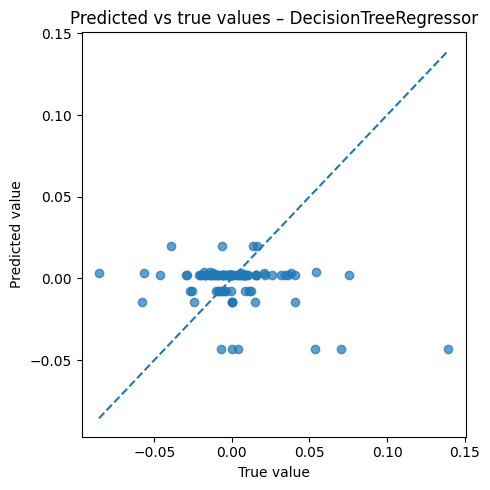

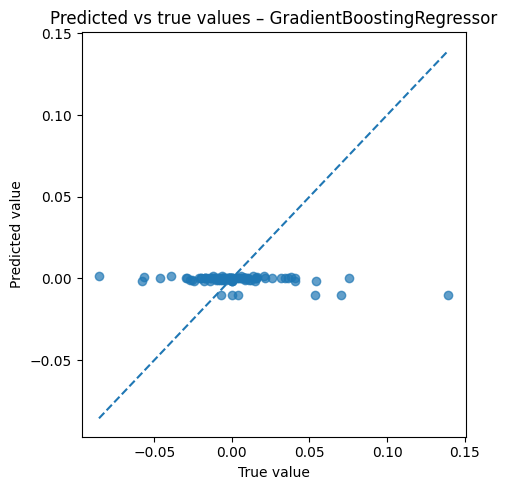

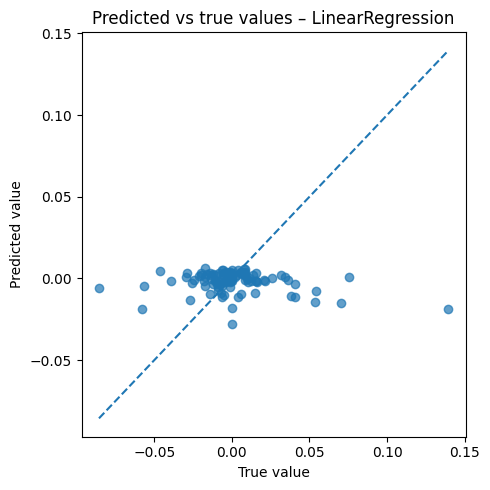

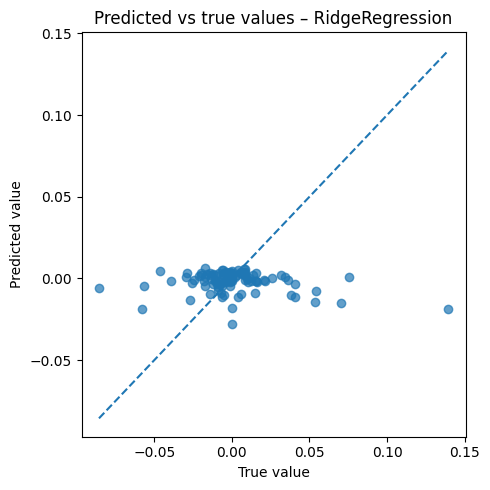

In [4]:
for model_name, subset in predictions.groupby("model"):
    sample = subset.head(300)

    plt.figure(figsize=(5, 5))
    plt.scatter(sample["y_true"], sample["y_pred"], alpha=0.7)

    min_value = min(sample["y_true"].min(), sample["y_pred"].min())
    max_value = max(sample["y_true"].max(), sample["y_pred"].max())

    plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
    plt.title(f"Predicted vs true values – {model_name}")
    plt.xlabel("True value")
    plt.ylabel("Predicted value")
    plt.tight_layout()
    plt.show()


## 5. Residual distributions

The regression output schema stores:

```txt
error = y_pred - y_true
```

Residuals help show whether prediction errors are centered around zero and whether some models produce wider error distributions.


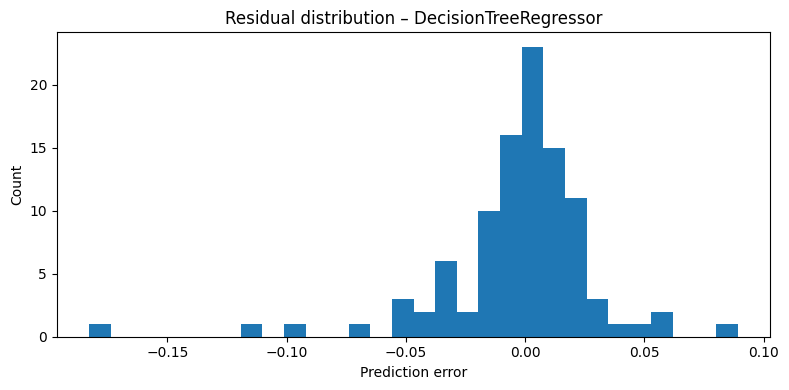

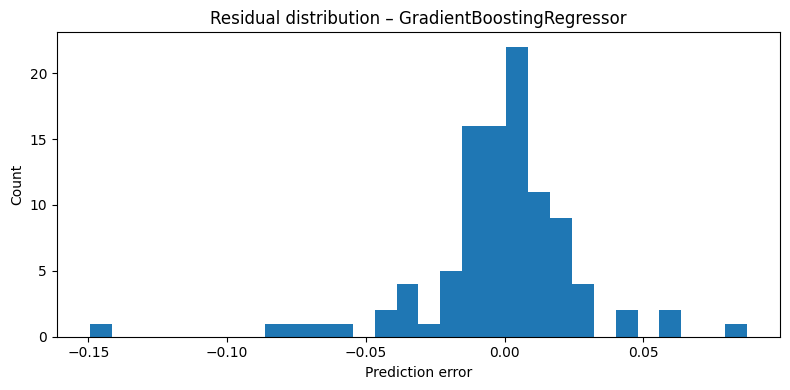

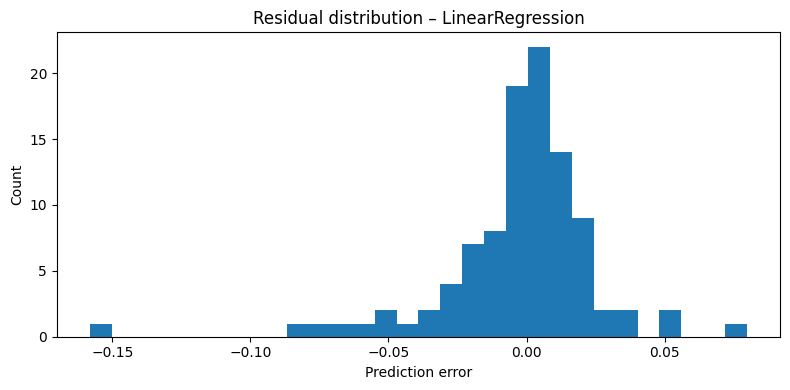

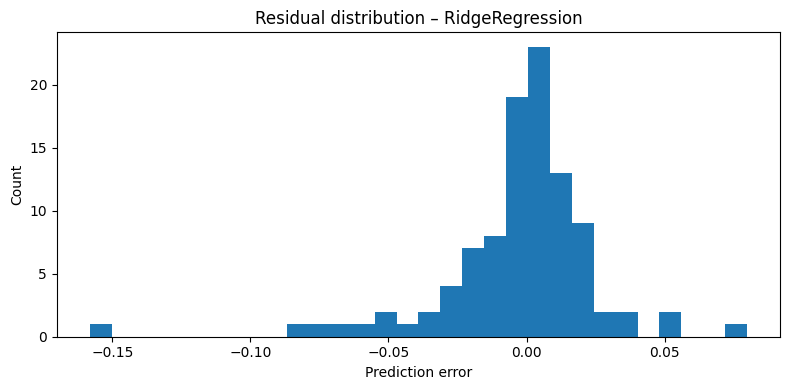

In [5]:
for model_name, subset in predictions.groupby("model"):
    plt.figure(figsize=(8, 4))
    plt.hist(subset["error"], bins=30)
    plt.title(f"Residual distribution – {model_name}")
    plt.xlabel("Prediction error")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


## 6. Loss history

Loss history is available for iterative models that export training loss.


In [6]:
loss_history.head()


,run_id,workflow,dataset,model,split,iteration,loss
0,linear_regression_baseline,regression,stock_ohlcv_engineered,LinearRegression,train,0,0.000563
1,linear_regression_baseline,regression,stock_ohlcv_engineered,LinearRegression,train,1,0.000561
2,linear_regression_baseline,regression,stock_ohlcv_engineered,LinearRegression,train,2,0.000558
3,linear_regression_baseline,regression,stock_ohlcv_engineered,LinearRegression,train,3,0.000556
4,linear_regression_baseline,regression,stock_ohlcv_engineered,LinearRegression,train,4,0.000554


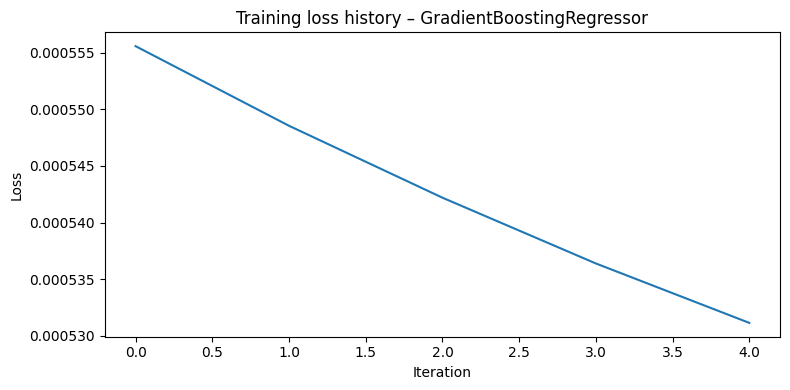

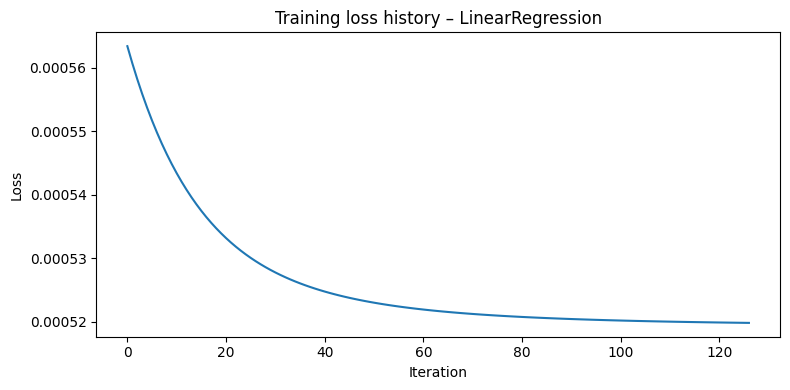

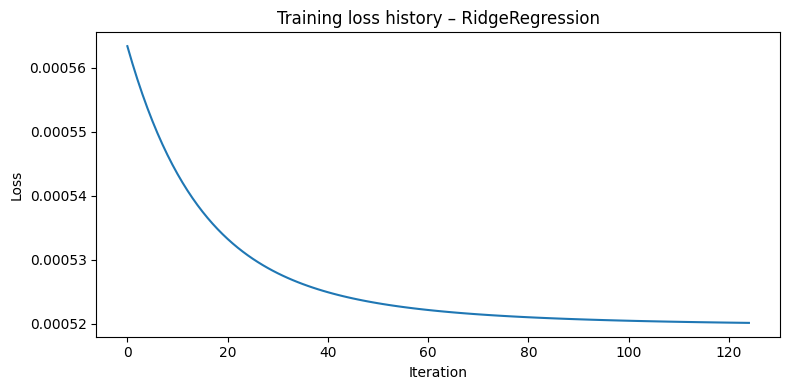

In [7]:
for model_name, subset in loss_history.groupby("model"):
    plt.figure(figsize=(8, 4))
    plt.plot(subset["iteration"], subset["loss"])
    plt.title(f"Training loss history – {model_name}")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.show()


## 7. Interpretation notes

This notebook is for visualization only.

The stock-return regression task is noisy. Negative R2 values indicate that the tested models did not explain the target variance better than a simple mean baseline on the test split.

That does not mean the workflow failed. It means the workflow correctly exposes the practical difficulty of short-horizon return prediction.
